# ERA5 Land Data Processing

This notebook process the raw data downloaded from GEE server.

In [ ]:
# Load libraries

import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
print('Libraries loaded.')

pd.set_option('display.expand_frame_repr', False)

Libraries loaded.


In [66]:
# Imports and configurations -----------------------------------------------------------------------

RUN_LABEL   = 'global'  # short name for this run
RUN_VERSION = 'v6'         # increment this for each new run
RUN_NAME   = f'{RUN_LABEL}_{RUN_VERSION}'

# Paths and directories -----------------------------------------------------------------------
BASE_OUT_DIR = r'C:\Users\ibekar\Documents\GitProjects\TGPF'  # Windows
# BASE_OUT_DIR = '/Users/ibekar/Github/TGPF'                  # Mac

fire_metrics_path = os.path.join(BASE_OUT_DIR, 'runs', RUN_NAME, 'fire_metrics', f'master_{RUN_NAME}.csv')
print(f'fire metrics csv file is: {fire_metrics_path}')

input_dir = os.path.join(BASE_OUT_DIR, 'inputs', 'raw_data', 'era5_raw')
save_dir = os.path.join(BASE_OUT_DIR, 'runs', RUN_NAME, 'inputs')
os.makedirs(save_dir, exist_ok=True)
print(f'input directory: {input_dir}')
print(f'save directory: {save_dir}')

fire metrics csv file is: C:\Users\ibekar\Documents\GitProjects\TGPF\runs\global_v6\fire_metrics\master_global_v6.csv
input directory: C:\Users\ibekar\Documents\GitProjects\TGPF\inputs\raw_data\era5_raw
save directory: C:\Users\ibekar\Documents\GitProjects\TGPF\runs\global_v6\inputs


In [67]:
# Load raw ERA5 file
only_files = glob.glob(input_dir + "/*.csv")
era5_raw = pd.concat((pd.read_csv(f) for f in only_files))
print(era5_raw.head())

   eco_id                        eco_name        date  temperature_K  precip_m
0     100  Madagascar succulent woodlands  2002-01-01     295.817072  0.031535
1     100  Madagascar succulent woodlands  2002-01-02     295.766950  0.052506
2     100  Madagascar succulent woodlands  2002-01-03     296.098753  0.032128
3     100  Madagascar succulent woodlands  2002-01-04     296.854065  0.004063
4     100  Madagascar succulent woodlands  2002-01-05     295.893549  0.000083


In [68]:
print(era5_raw.columns)
print(era5_raw.dtypes)
print(era5_raw.isnull().sum())

Index(['eco_id', 'eco_name', 'date', 'temperature_K', 'precip_m'], dtype='object')
eco_id             int64
eco_name          object
date              object
temperature_K    float64
precip_m         float64
dtype: object
eco_id                0
eco_name              0
date                  0
temperature_K    289278
precip_m         289278
dtype: int64


## Missing Data Control Center

In [69]:
total_rows = len(era5_raw)
missing_rows = era5_raw["precip_m"].isna().sum()
print(f"Total rows: {total_rows:,}")
print(f"Missing rows: {missing_rows:,}")
print(f"Missing fraction: {missing_rows/total_rows:.1%}")

Total rows: 7,416,036
Missing rows: 289,278
Missing fraction: 3.9%


In [71]:
missing_era5 = era5_raw[era5_raw["precip_m"].isna()]
print(missing_era5["eco_name"].nunique())

33


In [72]:
missing_era5.groupby("eco_name")[["temperature_K", "precip_m"]].describe()

temperature_K                              precip_m                             
                                                           count mean std min 25% 50% 75% max    count mean std min 25% 50% 75% max
eco_name                                                                                                                           
Aldabra Island xeric scrub                                   0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Amsterdam-Saint Paul Islands temperate grasslands            0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Ascension scrub and grasslands                               0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Bermuda subtropical conifer forests                          0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Cayos Miskitos-San Andrés and Providencia moist...           0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Central Polynesian tropical moist forests                    0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Christmas and Cocos Islands tropical forests                 0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Clipperton Island shrub and grasslands                       0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Cocos Island moist forests                                   0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Cook Islands tropical moist forests                          0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Eastern Micronesia tropical moist forests                    0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Fernando de Noronha-Atol das Rocas moist forests             0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Granitic Seychelles forests                                  0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Ile Europa and Bassas da India xeric scrub                   0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Juan Fernández Islands temperate forests                     0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Kermadec Islands subtropical moist forests                   0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Lord Howe Island subtropical forests                         0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Malpelo Island xeric scrub                                   0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Norfolk Island subtropical forests                           0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Northwest Hawai'i scrub                                      0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Ogasawara subtropical moist forests                          0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Rapa Nui and Sala y Gómez subtropical forests                0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
San Félix-San Ambrosio Islands temperate forests             0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
South China Sea Islands                                      0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
St. Helena scrub and woodlands                               0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
St. Peter and St. Paul Rocks                                 0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Tongan tropical moist forests                                0.0  NaN NaN NaN NaN NaN NaN NaN      0.0  NaN NaN NaN NaN NaN NaN NaN
Trindade-Martin Vaz Islands tropical forests                 0.0  NaN NaN NaN NaN NaN NaN N

In [73]:
era5 = era5_raw.dropna(subset=["temperature_K", "precip_m"]).copy()

print(f"Rows before: {len(era5):,}")
print(f"Rows after: {len(era5):,}")
print(f"Remaining missing values: {era5[['temperature_K', 'precip_m']].isna().sum().sum()}")

Rows before: 7,126,758
Rows after: 7,126,758
Remaining missing values: 0


# Unit Conversion

In [74]:
# Unit conversion
era5["temperature_C"] = era5["temperature_K"] - 273.15
era5["precip_mm"] = era5["precip_m"] * 1000
print(era5.head())

   eco_id                        eco_name        date  temperature_K  precip_m  temperature_C  precip_mm
0     100  Madagascar succulent woodlands  2002-01-01     295.817072  0.031535      22.667072  31.534837
1     100  Madagascar succulent woodlands  2002-01-02     295.766950  0.052506      22.616950  52.506191
2     100  Madagascar succulent woodlands  2002-01-03     296.098753  0.032128      22.948753  32.128499
3     100  Madagascar succulent woodlands  2002-01-04     296.854065  0.004063      23.704065   4.063238
4     100  Madagascar succulent woodlands  2002-01-05     295.893549  0.000083      22.743549   0.082797


In [75]:
# Parse date and extract year and doy
era5["date"] = pd.to_datetime(era5["date"])
era5["year"] = era5["date"].dt.year
era5["doy"] = era5["date"].dt.dayofyear
print(era5.head())

   eco_id                        eco_name       date  temperature_K  precip_m  temperature_C  precip_mm  year  doy
0     100  Madagascar succulent woodlands 2002-01-01     295.817072  0.031535      22.667072  31.534837  2002    1
1     100  Madagascar succulent woodlands 2002-01-02     295.766950  0.052506      22.616950  52.506191  2002    2
2     100  Madagascar succulent woodlands 2002-01-03     296.098753  0.032128      22.948753  32.128499  2002    3
3     100  Madagascar succulent woodlands 2002-01-04     296.854065  0.004063      23.704065   4.063238  2002    4
4     100  Madagascar succulent woodlands 2002-01-05     295.893549  0.000083      22.743549   0.082797  2002    5


In [76]:
# Reorder columns
ordered_first = ['eco_id', 'eco_name', 'date', 'year', 'doy']

rest = [c for c in era5.columns if c not in ordered_first]

# Combine and reindex
era5 = era5[ordered_first + rest]
print(era5)

      eco_id                        eco_name       date  year  doy  temperature_K  precip_m  temperature_C  precip_mm
0        100  Madagascar succulent woodlands 2002-01-01  2002    1     295.817072  0.031535      22.667072  31.534837
1        100  Madagascar succulent woodlands 2002-01-02  2002    2     295.766950  0.052506      22.616950  52.506191
2        100  Madagascar succulent woodlands 2002-01-03  2002    3     296.098753  0.032128      22.948753  32.128499
3        100  Madagascar succulent woodlands 2002-01-04  2002    4     296.854065  0.004063      23.704065   4.063238
4        100  Madagascar succulent woodlands 2002-01-05  2002    5     295.893549  0.000083      22.743549   0.082797
...      ...                             ...        ...   ...  ...            ...       ...            ...        ...
8761       9             Eastern Arc forests 2025-12-27  2025  361     295.789468  0.020459      22.639468  20.458533
8762       9             Eastern Arc forests 2025-12-28 

# Climatological baselines

In [77]:
# Calculate climatological baselines

climatology = era5.groupby(['eco_id', 'doy']).agg({
    'temperature_C': 'mean',
    'precip_mm': 'mean'
}).reset_index()

climatology.rename(columns={
    'temperature_C': 'temp_climatology',
    'precip_mm': 'precip_climatology'
}, inplace=True)
print(climatology)

        eco_id  doy  temp_climatology  precip_climatology
0            1    1         19.476898            7.565224
1            1    2         19.725525            6.850542
2            1    3         19.788428            6.697198
3            1    4         19.801478            6.890912
4            1    5         19.792902            7.540840
...        ...  ...               ...                 ...
297553     846  362         12.462036            0.004318
297554     846  363         12.518308            0.023577
297555     846  364         12.288483            0.064896
297556     846  365         11.831928            0.003229
297557     846  366         11.632810            0.001155

[297558 rows x 4 columns]


In [78]:
# Save climatology to disk for use in validation notebook
climatology.to_csv(os.path.join(save_dir, 'era5_climatology_doy.csv'), index=False)
print(f'Climatology saved: {len(climatology)} rows')

Climatology saved: 297558 rows


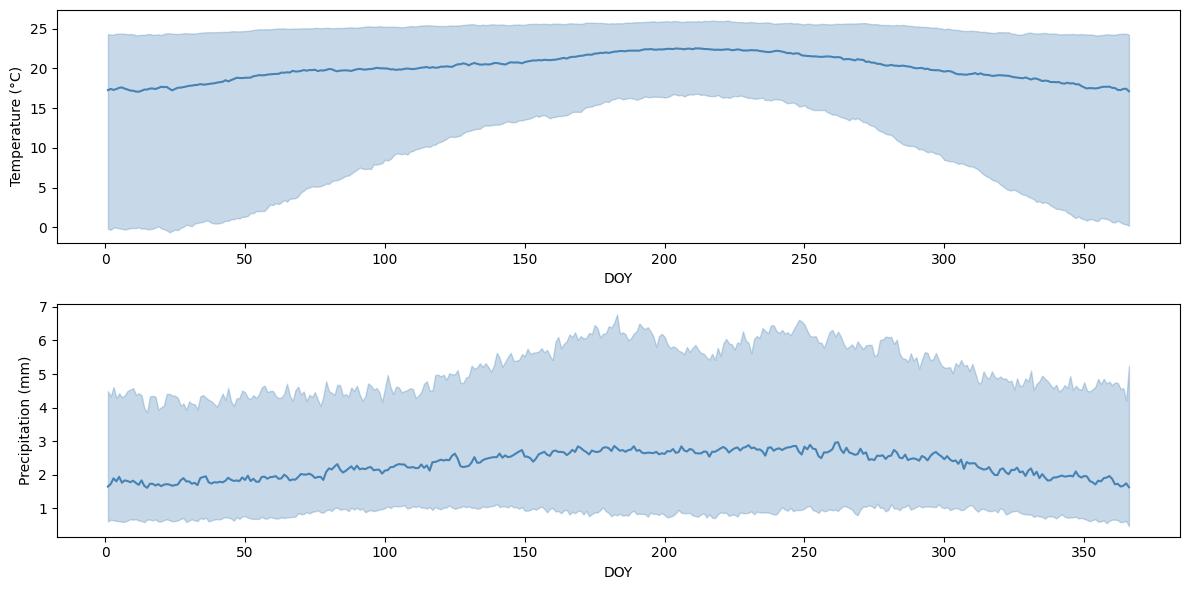

In [79]:
# Plot : Median seasonal cycle with IQR envelope --------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

for ax, var, label in zip(axes,
                           ['temp_climatology', 'precip_climatology'],
                           ['Temperature (°C)', 'Precipitation (mm)']):
    grouped = climatology.groupby('doy')[var]
    median  = grouped.median()
    q25     = grouped.quantile(0.25)
    q75     = grouped.quantile(0.75)

    ax.plot(median.index, median.values, color='steelblue', lw=1.5)
    ax.fill_between(median.index, q25, q75, alpha=0.3, color='steelblue')
    ax.set_xlabel('DOY')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

In [80]:
# Merge climatology back to main df
era5_clim = pd.merge(era5, climatology, on=['eco_id', 'doy'], how='left')

# Calculate anomalies
era5_clim["temp_anomaly"] = era5_clim["temperature_C"] - era5_clim["temp_climatology"]
era5_clim["precip_anomaly"] = era5_clim["precip_mm"] - era5_clim["precip_climatology"]
era5_clim = era5_clim.drop(columns=['temperature_K', 'precip_m'])
print(era5_clim)

         eco_id                        eco_name       date  year  doy  temperature_C  precip_mm  temp_climatology  precip_climatology  temp_anomaly  precip_anomaly
0           100  Madagascar succulent woodlands 2002-01-01  2002    1      22.667072  31.534837         26.052637            9.473766     -3.385565       22.061072
1           100  Madagascar succulent woodlands 2002-01-02  2002    2      22.616950  52.506191         25.749081           11.113839     -3.132131       41.392352
2           100  Madagascar succulent woodlands 2002-01-03  2002    3      22.948753  32.128499         25.748347            8.453466     -2.799594       23.675032
3           100  Madagascar succulent woodlands 2002-01-04  2002    4      23.704065   4.063238         25.549864            7.660107     -1.845799       -3.596869
4           100  Madagascar succulent woodlands 2002-01-05  2002    5      22.743549   0.082797         25.544008            7.465437     -2.800459       -7.382640
...         ... 

In [ ]:
# Load fire metrics and check missing ERA5 ecoregions
fire_metrics = pd.read_csv(fire_metrics_path)

missing_eco_ids = missing_era5["eco_id"].unique()
overlap = fire_metrics[fire_metrics["eco_id"].isin(missing_eco_ids)]
print(f"Fire metric rows from empty ERA5 ecoregions: {len(overlap)}")
print(overlap["eco_id"].nunique(), "unique ecoregions")

# Drop missing ERA5 region
fire_metrics_clean = fire_metrics[~fire_metrics["eco_id"].isin(missing_eco_ids)].copy()
print(f"Rows before: {len(fire_metrics):,}")
print(f"Rows after: {len(fire_metrics_clean):,}")

Fire metric rows from empty ERA5 ecoregions: 7
1 unique ecoregions


In [90]:
#and merge with ERA5 data
metrics = fire_metrics_clean[['eco_id', 'year', 'onset_doy']]

era5_full = era5_clim.merge(metrics, on=['eco_id', 'year'], how='left')
print(era5_full)

         eco_id                        eco_name       date  year  doy  temperature_C  precip_mm  temp_climatology  precip_climatology  temp_anomaly  precip_anomaly  onset_doy
0           100  Madagascar succulent woodlands 2002-01-01  2002    1      22.667072  31.534837         26.052637            9.473766     -3.385565       22.061072        NaN
1           100  Madagascar succulent woodlands 2002-01-02  2002    2      22.616950  52.506191         25.749081           11.113839     -3.132131       41.392352        NaN
2           100  Madagascar succulent woodlands 2002-01-03  2002    3      22.948753  32.128499         25.748347            8.453466     -2.799594       23.675032        NaN
3           100  Madagascar succulent woodlands 2002-01-04  2002    4      23.704065   4.063238         25.549864            7.660107     -1.845799       -3.596869        NaN
4           100  Madagascar succulent woodlands 2002-01-05  2002    5      22.743549   0.082797         25.544008            

In [91]:
# Calculate actual calendar date for lag window calculations

era5_full['onset_date'] = pd.to_datetime(era5_full['year'].astype(str)) + \
                          pd.to_timedelta(era5_full['onset_doy'] - 1, unit='D')

# Anomaly Calculation

In [113]:
# Compute lagged window anomalies

lags = [30, 45, 60, 90]

# Get valid ecoregion-year pairs with onset
valid_onsets = fire_metrics_clean[['eco_id', 'year', 'onset_doy']].dropna(subset=['onset_doy'])
valid_onsets['onset_date'] = pd.to_datetime(valid_onsets['year'].astype(str)) + \
                             pd.to_timedelta(valid_onsets['onset_doy'] - 1, unit='D')

results = []

for _, row in valid_onsets.iterrows():
    eco_id     = row['eco_id']
    year       = row['year']
    onset_date = row['onset_date']

    eco_era5 = era5_clim[era5_clim['eco_id'] == eco_id]

    record = {'eco_id': eco_id, 'year': year}

    for lag in lags:
        window = eco_era5[
            (eco_era5['date'] >= onset_date - pd.Timedelta(days=lag)) &
            (eco_era5['date'] <  onset_date)
        ]
        record[f'temp_anomaly_{lag}d']    = window['temp_anomaly'].mean()
        record[f'precip_anomaly_{lag}d']  = window['precip_anomaly'].mean()
        record[f'window_days_{lag}d']     = len(window)

    results.append(record)

anomaly_df = pd.DataFrame(results)
print(anomaly_df.head())
print(anomaly_df.shape)
print(anomaly_df.isnull().sum())

   eco_id  year  temp_anomaly_30d  precip_anomaly_30d  window_days_30d  temp_anomaly_45d  precip_anomaly_45d  window_days_45d  temp_anomaly_60d  precip_anomaly_60d  window_days_60d  temp_anomaly_90d  precip_anomaly_90d  window_days_90d
0       1  2003          0.070401            0.436633               30         -0.148986            0.258227               45         -0.137756            0.789682               60         -0.175300            0.788038               90
1       1  2004         -0.183076            0.183724               30          0.118395           -0.329260               45          0.137116           -0.520779               60          0.096936           -0.208620               90
2       1  2005          0.163124           -1.304048               30          0.137944           -0.969478               45          0.041969           -0.720020               60         -0.050983           -0.430535               90
3       1  2006          0.178089            0.103682   

In [ ]:
nan_rows = anomaly_df[anomaly_df.isnull().any(axis=1)][['eco_id', 'year']]
check = nan_rows.merge(fire_metrics[['eco_id', 'year', 'onset_doy', 'peak_doy']], 
                       on=['eco_id', 'year'], how='left')
print(check)

In [ ]:
fire_metrics_final = fire_metrics.merge(anomaly_df, on=['eco_id', 'year'], how='left')
print(fire_metrics_final)

In [ ]:
keep_cols = [
    # identifiers
    'eco_id', 'eco_name', 'biome_num', 'biome_name', 'year',
    # primary fire timing metrics
    'onset_doy', 'peak_doy', 'end_doy', 'season_length',
    # detection volume
    'n_detections',
    # quality flags
    'pct_years_valid', 'bimodal_flag_eco', 'frac_flagged',
    'mean_profile_corr', 'cv_peak_doy',
    # climate predictors (added by anomaly merge)
    'temp_anomaly_30d', 'precip_anomaly_30d',
    'temp_anomaly_45d', 'precip_anomaly_45d',
    'temp_anomaly_60d', 'precip_anomaly_60d',
    'temp_anomaly_90d', 'precip_anomaly_90d',
]

fire_metrics_final = fire_metrics_final[keep_cols]

In [ ]:
fire_metrics_final.to_csv(os.path.join(save_dir, 'era5_anomalies_by_lag.csv'), index=False)